**Week 1 Jupyter Notebook – Linear Regression 1 Instructions**

Each week, you will apply the concepts of that week to your Integrated Capstone Project’s dataset. In preparation for Milestone One, create a Jupyter Notebook (similar to in Module B, semester two) that illustrates these lessons. There are no specific questions to answer in your Jupyter Notebook files in this course; your general goal is to analyze your data, using the methods you have learned about in this course and in this program, and draw interesting conclusions. 

For Week 1, include concepts such as linear regression with polynomial terms, interaction terms, multicollinearity, variance inflation factor and regression, and categorical and continuous features. Complete your Jupyter Notebook homework by 11:59 pm ET on Sunday. 

In Week 7, you will compile your findings from your Jupyter Notebook homework into your Milestone One assignment for grading. For full instructions and the rubric for Milestone One, refer to the following link. 

# Week 1: Polynomial terms, interactions, and multicollinearity

**Assignment coverage:** continuous and categorical predictors; additive OLS; quadratic terms; an interaction; multicollinearity; variance inflation factors; held-out evaluation; residual diagnostics; evidence-based conclusions.

**Expanded coverage:** this notebook applies the weekly methods independently to all three CSV files in `DATA`. Each dataset has its own response, preparation, model selection, diagnostics, and conclusions. Metrics with different outcomes or units must not be ranked against one another.

## Results across all three datasets

- **accepted_2007_to_2018Q4.csv**: Quadratic + interaction; test RMSE **3.064 percentage points**, MAE **2.415 percentage points**, R² **0.492**, test n = **4,800**. Development-mean baseline RMSE: **4.299 percentage points**.
- **Loan_Default.csv**: Quadratic + interactions; test RMSE **0.442 percentage points**, MAE **0.349 percentage points**, R² **0.355**, test n = **4,800**. Development-mean baseline RMSE: **0.551 percentage points**.
- **bank_customers.csv**: Additive OLS; test RMSE **10.817 years**, MAE **8.857 years**, R² **-0.083**, test n = **8**. Development-mean baseline RMSE: **12.141 years**.

Each dataset now has its own full application of this week's required methods. LendingClub models issued rates in a 2015 cohort; Loan_Default models observed rates in a heavily selected subset; bank_customers models historical account tenure. Their errors use different populations and, for the bank file, different units. The small bank holdout is a method demonstration, not a reliable performance claim. The dataset-specific conclusions above explain the observed selection, shrinkage, or component tradeoff. No result establishes causality or future-cohort validity.

The prose describes this saved run. If inputs or parameters change, rerun all code and revise the narrative to match.

## A. accepted_2007_to_2018Q4.csv — independent analysis

## Context & methods

**Question:** How well can application and contract attributes explain the issued
interest rate of a loan, and what does this week's method change?
The response is `int_rate`, measured in percent; prediction errors are reported in
**percentage points (pp)**. A rate of 12 is 12%, not 0.12%.

**Source:** `DATA/accepted_2007_to_2018Q4.csv`. The analysis takes a reproducible,
uniform sample of 24,000 eligible loans issued in **2015**, scanning the whole CSV
in chunks. One origination year limits changes in lending policy across years.
The model explains rates on accepted loans; it does not estimate default risk,
approval probability, or causal effects. Weeks 1–3 deliberately reuse the same
sample and 60%/20%/20% training/validation/test partitions for comparability.

### Key assumptions

- Rows represent distinct loans; unique sampled loan IDs are checked. The file
  does not provide a usable borrower-group design here, so repeat-borrower
  dependence remains possible. A random split evaluates same-cohort performance,
  not future-year generalization.
- `int_rate` must be observed and in (0, 100]. Missing predictors are imputed using
  training data. Large positive incomes and utilization over 100 are retained;
  they are not silently removed. Log transforms reduce income/amount skew.
- Grade, subgrade, installment, funded amounts, payment/recovery fields, and later
  loan status are excluded from predictors: some directly encode pricing, are
  redundant, or occur after origination. Contract term and verification status
  make this an **issued-rate explanation**, not a pre-application quote model.
- Categorical values use one-hot indicators with a dropped reference level.
  Continuous variables are standardized inside each fitted pipeline. Employment
  duration is approximate and top-coded. No external data dictionary/rubric was
  included, so undocumented coding and units are not invented.
- Hyperparameters and model families are chosen without test outcomes. Every
  learned transformation is fitted inside the appropriate training/CV partition.
  The final test is opened once per notebook; the three notebooks are related
  instructional comparisons, not independent confirmatory experiments.

**Run instructions:** Install `requirements-notebooks.txt`, select a Python
kernel, and use **Restart Kernel → Run All**. Each notebook is self-contained and
reads the original CSV; no earlier notebook or temporary cache is required.

### 1. Set up a reproducible Python environment

Imports, a fixed random seed, readable charts, and explicit package versions make the analysis auditable.

In [1]:
from pathlib import Path
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import sklearn
from IPython.display import display, Markdown
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits

# A fixed seed and bounded numerical threads make the workflow repeatable.
SEED = 42
thread_limit = threadpool_limits(limits=1)
warnings.filterwarnings('error', category=ConvergenceWarning)
pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
plt.rcParams.update({'figure.figsize': (10, 4.5), 'figure.dpi': 115,
                     'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.18, 'axes.axisbelow': True})
BLUE, ORANGE, GRAY = '#245E91', '#B96520', '#50545A'

# Support opening from the repository itself or its parent workspace.
data_candidates = [Path.cwd() / 'DATA',
                   Path.cwd() / 'Data-Science-Capstone-DX799' / 'DATA']
DATA_DIR = next((p for p in data_candidates if p.is_dir()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Open this notebook from the repository or its parent; DATA is required.')
display(pd.Series({'Python': platform.python_version(), 'pandas': pd.__version__,
                   'NumPy': np.__version__, 'scikit-learn': sklearn.__version__,
                   'SciPy': scipy.__version__, 'seed': SEED}, name='Execution environment'))

Python          3.13.5
pandas           3.0.0
NumPy            2.4.1
scikit-learn     1.8.0
SciPy           1.17.0
seed                42
Name: Execution environment, dtype: object

### 2. Load and reconcile the 2015 lending cohort

The large CSV is streamed in chunks. Random priorities give every eligible row the same inclusion probability.

In [2]:
SOURCE = DATA_DIR / 'accepted_2007_to_2018Q4.csv'
COHORT_YEAR = '2015'
SAMPLE_SIZE = 24_000
USECOLS = ['id', 'loan_amnt', 'funded_amnt', 'int_rate', 'term', 'annual_inc',
           'fico_range_low', 'fico_range_high', 'dti', 'revol_util', 'emp_length',
           'earliest_cr_line', 'open_acc', 'home_ownership', 'verification_status',
           'purpose', 'issue_d']
rng = np.random.default_rng(SEED)
sample = pd.DataFrame()
source_rows = cohort_rows = eligible_rows = 0

# Read the complete file in chunks, then retain the smallest independent random
# priorities. This is a uniform sample without replacement, not the first 24,000
# rows (the source is not randomly ordered). Memory stays bounded.
for chunk in pd.read_csv(SOURCE, usecols=USECOLS, chunksize=150_000, low_memory=False):
    source_rows += len(chunk)
    cohort = chunk.loc[chunk['issue_d'].astype('str').str.endswith(COHORT_YEAR)].copy()
    cohort_rows += len(cohort)
    rate = pd.to_numeric(cohort['int_rate'], errors='coerce')
    cohort = cohort.loc[rate.gt(0) & rate.le(100)].copy()
    eligible_rows += len(cohort)
    if not cohort.empty:
        cohort['_priority'] = rng.random(len(cohort))
        sample = pd.concat([sample, cohort.nsmallest(SAMPLE_SIZE, '_priority')])
        sample = sample.nsmallest(SAMPLE_SIZE, '_priority')
sample = sample.drop(columns='_priority').reset_index(drop=True)
assert len(sample) == SAMPLE_SIZE and sample['id'].notna().all()
assert sample['id'].is_unique, 'Repeated loan IDs require a grouped split.'
assert sample['int_rate'].between(0, 100, inclusive='right').all()
display(pd.Series({'source CSV rows': source_rows, '2015 rows': cohort_rows,
                   'eligible positive-rate rows': eligible_rows,
                   'excluded missing/invalid rates': cohort_rows - eligible_rows,
                   'sampled loans': len(sample), 'source bytes': SOURCE.stat().st_size},
                  name='Source and cohort reconciliation'))
# Exclude identifiers and free-text personal information from displayed records.
display(sample[['loan_amnt', 'int_rate', 'term', 'annual_inc',
                'fico_range_low', 'dti', 'home_ownership']].head())

source CSV rows                      2260701
2015 rows                             421095
eligible positive-rate rows           421095
excluded missing/invalid rates             0
sampled loans                          24000
source bytes                      1675133810
Name: Source and cohort reconciliation, dtype: int64

,loan_amnt,int_rate,term,annual_inc,fico_range_low,dti,home_ownership
0,"20,225.0000",18.8400,60 months,"90,000.0000",685.0000,12.5200,RENT
1,"35,000.0000",7.8900,36 months,"140,000.0000",775.0000,8.7200,MORTGAGE
2,"10,000.0000",12.3900,36 months,"74,000.0000",695.0000,13.3500,RENT
3,"21,275.0000",18.4900,60 months,"210,000.0000",695.0000,3.3500,RENT
4,"31,175.0000",11.4900,36 months,"185,000.0000",695.0000,13.8600,RENT


### 3. Engineer interpretable features and reserve evaluation data

Only row-wise feature construction happens before splitting. The final test outcomes are not inspected during model selection.

In [3]:
# These are row-wise transformations with fixed rules, so they do not learn from
# validation/test data. Imputation, scaling, and encoding are fitted later.
X = pd.DataFrame(index=sample.index)
X['log_loan_amount'] = np.log1p(sample['loan_amnt'].where(sample['loan_amnt'] > 0))
X['log_annual_income'] = np.log1p(sample['annual_inc'].where(sample['annual_inc'] >= 0))
X['fico_mid'] = (sample['fico_range_low'] + sample['fico_range_high']) / 2
X['dti'] = sample['dti'].where(sample['dti'] >= 0)
X['revol_util'] = sample['revol_util'].where(sample['revol_util'] >= 0)
# '< 1 year' is represented by 0.5; '10+ years' by 10 (a top-coded value).
employment_map = {'< 1 year': 0.5, '1 year': 1, '10+ years': 10}
employment_map.update({f'{i} years': i for i in range(2, 10)})
X['employment_years'] = sample['emp_length'].map(employment_map)
issued = pd.to_datetime(sample['issue_d'], format='%b-%Y', errors='coerce')
first_credit = pd.to_datetime(sample['earliest_cr_line'], format='%b-%Y', errors='coerce')
X['credit_history_years'] = ((issued - first_credit).dt.days / 365.25).clip(lower=0)
X['open_acc'] = sample['open_acc'].where(sample['open_acc'] >= 0)
NUMERIC = list(X.columns)
CATEGORICAL = ['term', 'home_ownership', 'verification_status', 'purpose']
for name in CATEGORICAL:
    X[name] = sample[name].str.strip().astype(object).where(sample[name].notna(), np.nan)
y = sample['int_rate'].astype(float)

# Reserve the test partition before any data-driven model selection.
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_dev, y_dev, test_size=0.25, random_state=SEED)
assert not (set(X_train.index) & set(X_valid.index) or
            set(X_dev.index) & set(X_test.index))
assert len(X_train) + len(X_valid) + len(X_test) == len(sample)
display(pd.Series({'training': len(X_train), 'validation': len(X_valid),
                   'test (sealed until final evaluation)': len(X_test)}, name='Partition sizes'))
display(X_train.isna().mean().mul(100).sort_values(ascending=False)
        .rename('Training missing (%)').to_frame())

training                                14400
validation                               4800
test (sealed until final evaluation)     4800
Name: Partition sizes, dtype: int64

,Training missing (%)
employment_years,5.7708
revol_util,0.0347
log_loan_amount,0.0000
log_annual_income,0.0000
fico_mid,0.0000
dti,0.0000
credit_history_years,0.0000
open_acc,0.0000
term,0.0000
home_ownership,0.0000


### 4. Define preprocessing and evaluation helpers

Median imputation and scaling occur inside the estimator pipeline. Dummy encoding keeps categorical predictors distinct from continuous predictors.

In [4]:
class SelectedPolynomialTerms(TransformerMixin, BaseEstimator):
    """Append selected quadratic/interaction terms to standardized numeric data."""
    def __init__(self, mode='linear', fico_index=2, dti_index=3):
        self.mode = mode
        self.fico_index = fico_index
        self.dti_index = dti_index

    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        result = np.asarray(X)
        fico, dti = result[:, self.fico_index], result[:, self.dti_index]
        if self.mode in ('quadratic', 'interaction'):
            result = np.column_stack([result, fico ** 2, dti ** 2])
        if self.mode == 'interaction':
            result = np.column_stack([result, fico * dti])
        return result

    def get_feature_names_out(self, input_features=None):
        names = list(input_features)
        if self.mode in ('quadratic', 'interaction'):
            names += ['fico_mid_squared', 'dti_squared']
        if self.mode == 'interaction':
            names += ['fico_mid_x_dti']
        return np.asarray(names, dtype=object)

def make_preprocessor(mode='linear', numeric=None, categorical=None):
    """Fit all learned preparation inside a pipeline or cross-validation fold."""
    numeric = NUMERIC if numeric is None else numeric
    categorical = CATEGORICAL if categorical is None else categorical
    transformers = []
    if numeric:
        numeric_steps = [('impute', SimpleImputer(strategy='median')),
                         ('standardize', StandardScaler())]
        if mode != 'linear':
            numeric_steps += [('terms', SelectedPolynomialTerms(mode=mode))]
        transformers.append(('numeric', Pipeline(numeric_steps), numeric))
    if categorical:
        transformers.append(('categorical', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), categorical))
    return ColumnTransformer(transformers, verbose_feature_names_out=False)

def regression_metrics(actual, predicted):
    predicted = np.asarray(predicted).ravel()
    return {'RMSE (pp)': np.sqrt(mean_squared_error(actual, predicted)),
            'MAE (pp)': mean_absolute_error(actual, predicted),
            'R²': r2_score(actual, predicted)}

CV = KFold(n_splits=3, shuffle=True, random_state=SEED)

### 5. Explore training-set rate patterns

Explore only training outcomes. A curved FICO relationship motivates a quadratic term; an interaction allows the association of debt-to-income ratio with pricing to vary with FICO.

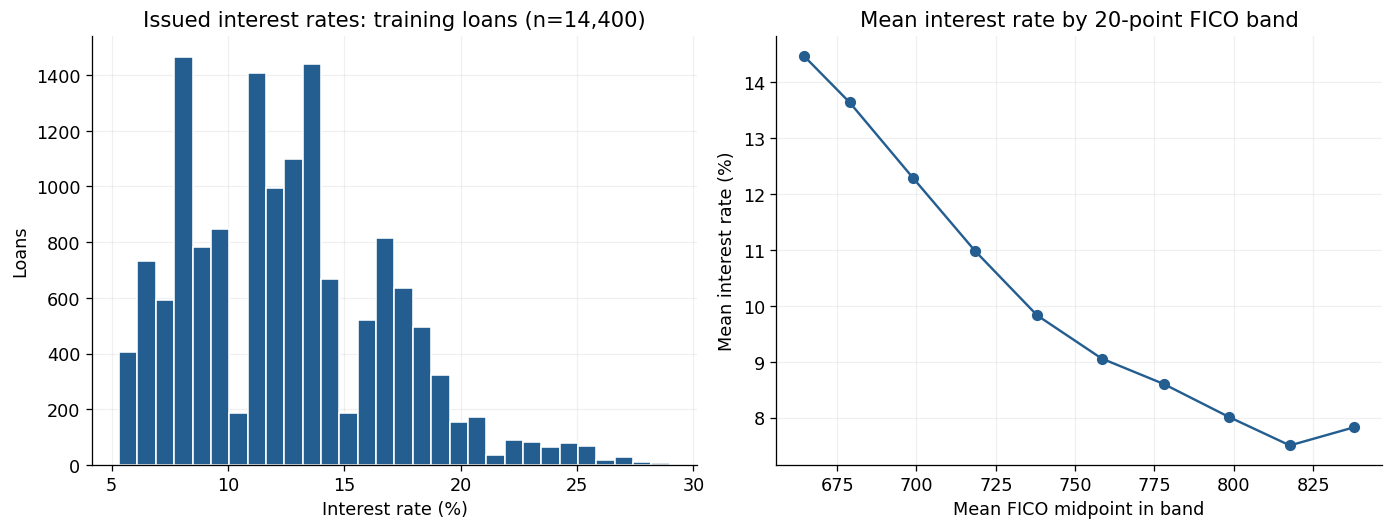

,fico_band,mean_fico,mean_rate,loans
0,"(650, 670]",664.4422,14.4792,2766
1,"(670, 690]",678.9459,13.6417,4625
2,"(690, 710]",698.9354,12.2881,3299
3,"(710, 730]",718.5045,10.9804,2004
4,"(730, 750]",738.0390,9.8290,847
5,"(750, 770]",758.3719,9.0563,441
6,"(770, 790]",777.9623,8.5998,239
7,"(790, 810]",798.4103,8.0119,117
8,"(810, 830]",817.6731,7.5004,52
9,"(830, 850]",838.0000,7.8270,10


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout='constrained')
axes[0].hist(y_train, bins=30, color=BLUE, edgecolor='white')
axes[0].set(title=f'Issued interest rates: training loans (n={len(y_train):,})',
            xlabel='Interest rate (%)', ylabel='Loans')
# Binned means reveal the trend without overplotting thousands of points.
exploration = X_train[['fico_mid']].assign(rate=y_train)
exploration['fico_band'] = pd.cut(exploration['fico_mid'], bins=np.arange(650, 871, 20))
fico_rates = exploration.groupby('fico_band', observed=True).agg(
    mean_fico=('fico_mid', 'mean'), mean_rate=('rate', 'mean'), n=('rate', 'size'))
axes[1].plot(fico_rates['mean_fico'], fico_rates['mean_rate'], 'o-', color=BLUE)
axes[1].set(title='Mean interest rate by 20-point FICO band',
            xlabel='Mean FICO midpoint in band', ylabel='Mean interest rate (%)')
plt.show()
display(fico_rates.reset_index().rename(columns={'n': 'loans'}))

Training rates average **12.60%** with a standard deviation of **4.35 pp**. The binned curve is descriptive; the table supplies the denominator for each band, and sparse high-FICO bands should not receive the same confidence as densely populated bands.

## Regression logic

The additive model is $\hat y=\beta_0+\sum_j\beta_jx_j+\sum_k\gamma_kD_k$,
where $D_k$ are category indicators. The quadratic model adds centered,
standardized FICO and DTI squared. The interaction model additionally adds
$z_{FICO}z_{DTI}$. All parent terms remain in the model (hierarchy).
The fit is still *linear in its coefficients*, even with nonlinear predictors.

In the interaction model, the fitted DTI slope in standardized units is
$\beta_{DTI}+2\beta_{DTI^2}z_{DTI}+\beta_{FICO\times DTI}z_{FICO}$.
A single interaction coefficient therefore does not describe a universal
effect. Coefficients are conditional associations, not causal estimates.

### 6. Quantify and resolve multicollinearity

For predictor $j$, $VIF_j=1/(1-R_j^2)$, where $R_j^2$ comes from regressing that predictor on all the others with an intercept. Values above 5 or 10 are screening heuristics, not automatic deletion rules. Exact redundancy gives infinite VIF.

In [6]:
def vif_table(frame):
    # Standardization improves numerical conditioning but does not remove
    # genuine collinearity. Auxiliary regressions include an intercept.
    values = StandardScaler().fit_transform(frame)
    rows = []
    for j, name in enumerate(frame.columns):
        others = np.delete(values, j, axis=1)
        r_squared = LinearRegression().fit(others, values[:, j]).score(others, values[:, j])
        vif = np.inf if 1 - r_squared < 1e-10 else 1 / (1 - r_squared)
        rows.append({'feature': name, 'VIF': vif})
    return pd.DataFrame(rows).sort_values('VIF', ascending=False)

raw_vif_features = sample.loc[X_train.index, [
    'loan_amnt', 'funded_amnt', 'fico_range_low', 'fico_range_high',
    'annual_inc', 'dti', 'open_acc']].astype(float)
raw_vif = vif_table(raw_vif_features.fillna(raw_vif_features.median()))
display(raw_vif)
# The modeling design removes funded_amnt and uses the FICO midpoint.
additive_prep = make_preprocessor().fit(X_train)
additive_design = pd.DataFrame(additive_prep.transform(X_train),
                              columns=additive_prep.get_feature_names_out())
clean_vif = vif_table(additive_design)
display(clean_vif.head(12))
# Individual dummy-column VIFs depend on the omitted reference category.
# Compare common reference levels without discarding a meaningful category.
common_references = [X_train[name].mode().iloc[0] for name in CATEGORICAL]
common_reference_prep = make_preprocessor().set_params(
    categorical__encode__drop=common_references).fit(X_train)
common_reference_design = pd.DataFrame(common_reference_prep.transform(X_train),
    columns=common_reference_prep.get_feature_names_out())
common_reference_vif = vif_table(common_reference_design)
display(common_reference_vif.head(8))
original_fit = LinearRegression().fit(additive_design, y_train)
reference_fit = LinearRegression().fit(common_reference_design, y_train)
reference_prediction_gap = np.max(np.abs(
    original_fit.predict(additive_design) - reference_fit.predict(common_reference_design)))
assert reference_prediction_gap < 1e-8
display(pd.Series(dict(zip(CATEGORICAL, common_references)), name='Common reference levels'))
# Reference-coded categories plus an intercept must have full column rank.
design_with_intercept = np.column_stack([np.ones(len(additive_design)), additive_design])
assert np.linalg.matrix_rank(design_with_intercept) == design_with_intercept.shape[1]

,feature,VIF
0,loan_amnt,inf
1,funded_amnt,inf
2,fico_range_low,inf
3,fico_range_high,inf
4,annual_inc,1.2346
5,dti,1.1771
6,open_acc,1.1582


,feature,VIF
14,purpose_debt_consolidation,29.3869
13,purpose_credit_card,22.6926
15,purpose_home_improvement,7.6826
20,purpose_other,6.1085
17,purpose_major_purchase,3.2320
18,purpose_medical,2.1259
22,purpose_small_business,1.9390
0,log_loan_amount,1.7993
1,log_annual_income,1.7312
19,purpose_moving,1.6765


,feature,VIF
0,log_loan_amount,1.7993
1,log_annual_income,1.7312
4,revol_util,1.4463
3,dti,1.3850
7,open_acc,1.3514
2,fico_mid,1.3389
10,home_ownership_RENT,1.2850
8,term_60 months,1.2640


term                            36 months
home_ownership                   MORTGAGE
verification_status       Source Verified
purpose                debt_consolidation
Name: Common reference levels, dtype: str

**Observed collinearity:** requested and funded loan amounts are identical for **100.0%** of training loans. Keeping both makes their separate coefficients unidentified. FICO lower/upper bounds are also nearly redundant. After retaining one amount and a FICO midpoint, the maximum VIF in the additive design is **29.39**. Centering helps with polynomial terms, but it cannot repair duplicated information. Changing only the categorical reference levels to the most common categories reduces the maximum dummy-column/design VIF to **1.80**, with a maximum OLS fitted-value change of **9.59e-14 pp**. The high original VIF therefore needs a coding-aware interpretation: individual dummy VIFs are reference-dependent, unlike the model's fitted space. The original coding is retained for consistent comparisons across Weeks 1–3.

### 7. Compare additive, quadratic, and interaction regressions

Three-fold cross-validation is restricted to training loans. Validation RMSE selects among the prespecified model forms; test outcomes remain sealed. A mean-only model establishes the improvement over a trivial prediction.

In [7]:
models = {'Mean baseline': DummyRegressor(strategy='mean')}
for label, mode in [('Additive OLS', 'linear'), ('Quadratic OLS', 'quadratic'),
                    ('Quadratic + interaction', 'interaction')]:
    models[label] = Pipeline([('prepare', make_preprocessor(mode)),
                              ('regress', LinearRegression())])
comparison_rows = []
for label, estimator in models.items():
    cv_rmse = -cross_val_score(estimator, X_train, y_train, cv=CV,
                              scoring='neg_root_mean_squared_error', n_jobs=1)
    estimator.fit(X_train, y_train)
    comparison_rows.append({'model': label,
        'Train RMSE (pp)': regression_metrics(y_train, estimator.predict(X_train))['RMSE (pp)'],
        'CV RMSE (pp)': cv_rmse.mean(), 'CV fold SD (pp)': cv_rmse.std(ddof=1),
        **regression_metrics(y_valid, estimator.predict(X_valid))})
validation_results = pd.DataFrame(comparison_rows).set_index('model')
display(validation_results.sort_values('RMSE (pp)'))
chosen_name = validation_results['RMSE (pp)'].idxmin()
assert chosen_name != 'Mean baseline', 'Investigate why no regression beats the baseline.'
chosen_model = clone(models[chosen_name]).fit(X_dev, y_dev)
test_prediction = chosen_model.predict(X_test)
test_metrics = regression_metrics(y_test, test_prediction)
baseline_prediction = DummyRegressor().fit(X_dev, y_dev).predict(X_test)
baseline_metrics = regression_metrics(y_test, baseline_prediction)
test_results = pd.DataFrame([test_metrics, baseline_metrics],
                           index=[chosen_name, 'Mean baseline'])
display(test_results.rename_axis('Final test model'))

,Train RMSE (pp),CV RMSE (pp),CV fold SD (pp),RMSE (pp),MAE (pp),R²
model,,,,,,
Quadratic + interaction,3.1002,3.1105,0.0175,3.1073,2.4457,0.4825
Quadratic OLS,3.1009,3.1109,0.0179,3.1078,2.4461,0.4823
Additive OLS,3.1174,3.1268,0.0203,3.1205,2.4631,0.4781
Mean baseline,4.3457,4.3457,0.0376,4.3200,3.4372,-0.0003


,RMSE (pp),MAE (pp),R²
Final test model,,,
Quadratic + interaction,3.0642,2.4146,0.4917
Mean baseline,4.2988,3.4020,-0.0004


### 8. Inspect coefficients and conditional predictions

Coefficients are on the transformed scale. Categorical coefficients compare with the printed reference category. The prediction curves fix other inputs at training medians/modes; they illustrate the fitted equation, not an intervention.

,Coefficient (pp)
purpose_house,4.0433
term_60 months,3.8405
purpose_small_business,3.3287
purpose_renewable_energy,2.6135
purpose_moving,2.4067
purpose_credit_card,-2.2711
verification_status_Verified,1.8999
fico_mid,-1.5652
purpose_vacation,1.1626
purpose_other,1.1401


term                      36 months
home_ownership             MORTGAGE
verification_status    Not Verified
purpose                         car
Name: Reference category, dtype: str

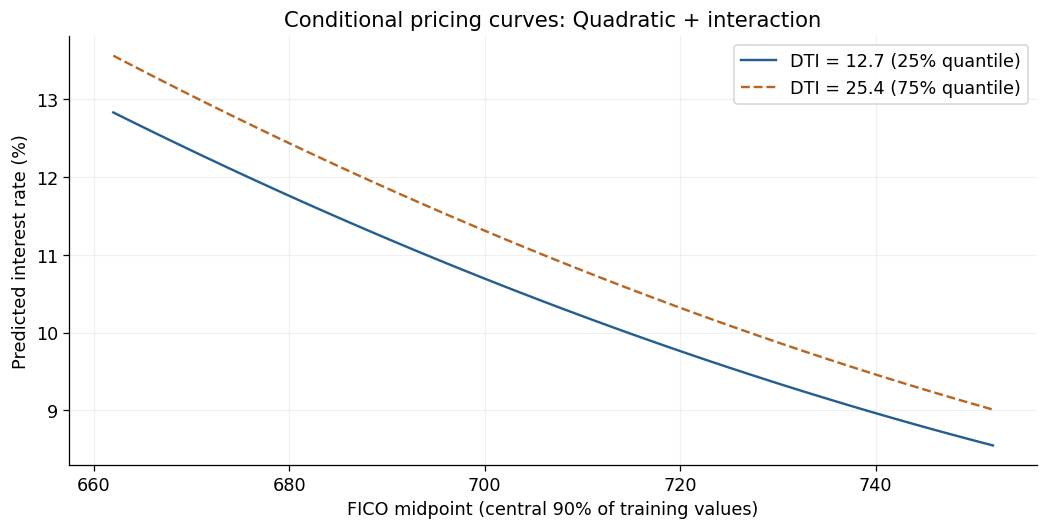

In [8]:
fitted_prep = chosen_model.named_steps['prepare']
coefficients = pd.Series(chosen_model.named_steps['regress'].coef_,
                         index=fitted_prep.get_feature_names_out(), name='Coefficient (pp)')
display(coefficients.loc[coefficients.abs().sort_values(ascending=False).head(12).index].to_frame())
encoder = fitted_prep.named_transformers_['categorical'].named_steps['encode']
display(pd.Series({name: categories[0] for name, categories in
                   zip(CATEGORICAL, encoder.categories_)}, name='Reference category'))
typical = {name: X_train[name].median() for name in NUMERIC}
typical.update({name: X_train[name].mode().iloc[0] for name in CATEGORICAL})
fico_grid = np.linspace(*X_train['fico_mid'].quantile([0.05, 0.95]), 80)
fig, ax = plt.subplots(figsize=(9, 4.5), layout='constrained')
for quantile, style, color in [(0.25, '-', BLUE), (0.75, '--', ORANGE)]:
    profile = pd.DataFrame([typical] * len(fico_grid))
    profile['fico_mid'] = fico_grid
    profile['dti'] = X_train['dti'].quantile(quantile)
    ax.plot(fico_grid, chosen_model.predict(profile), linestyle=style, color=color,
            label=f"DTI = {profile['dti'].iloc[0]:.1f} ({quantile:.0%} quantile)")
ax.set(title=f'Conditional pricing curves: {chosen_name}',
       xlabel='FICO midpoint (central 90% of training values)', ylabel='Predicted interest rate (%)')
ax.legend()
plt.show()

**Observed pricing relationships.** The fitted 60-month term coefficient is **+3.84 percentage points** relative to 36 months, conditional on the included borrower and contract attributes. The conditional curves also show lower fitted rates as FICO increases across the central training range, with higher fitted rates at the upper DTI quartile. These associations help explain pricing in this accepted-loan cohort; they do not show that changing a single borrower attribute would cause the same rate change.

### 9. Diagnose final-test residuals

Residuals are observed minus predicted rate. Check curvature, unequal spread, and tail deviations. A Q–Q plot diagnoses residual shape; normality is not required for computing an OLS prediction, but it matters for classical small-sample inference.

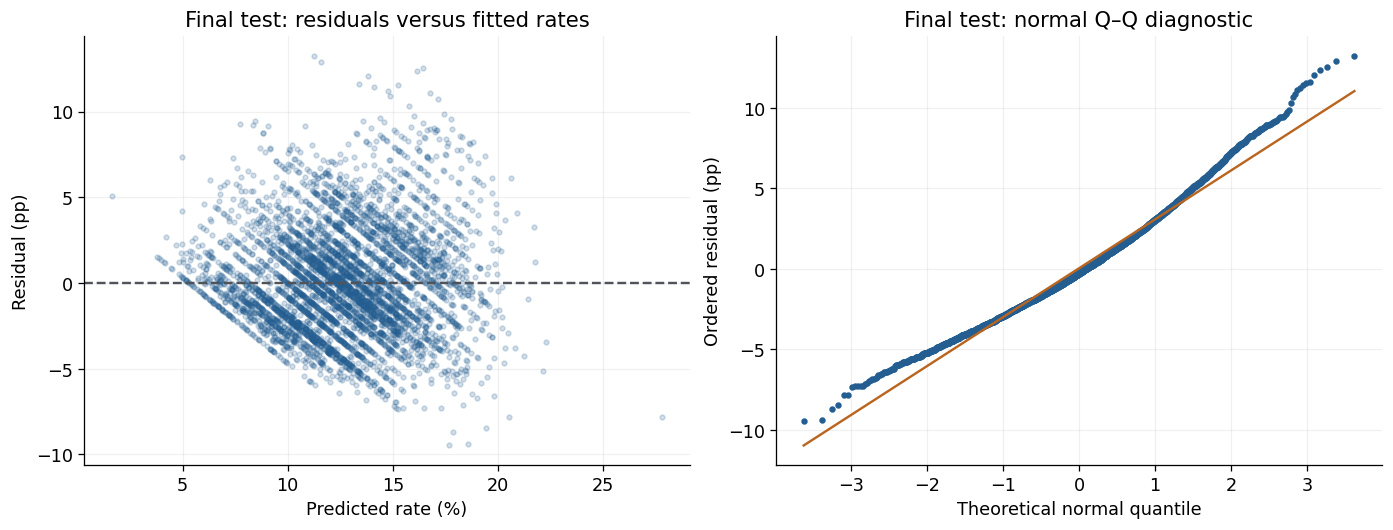

,loans,mean_residual_pp,residual_sd_pp
fitted_band,,,
"(1.6230000000000002, 10.126]",960,0.1859,2.5514
"(10.126, 11.869]",960,-0.0960,2.8349
"(11.869, 13.341]",960,-0.0457,2.9598
"(13.341, 15.215]",960,-0.2027,3.2020
"(15.215, 27.814]",960,0.3553,3.6362


In [9]:
from scipy.stats import probplot
residuals = y_test.to_numpy() - test_prediction
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout='constrained')
axes[0].scatter(test_prediction, residuals, s=9, alpha=0.20, color=BLUE)
axes[0].axhline(0, color=GRAY, linestyle='--')
axes[0].set(title='Final test: residuals versus fitted rates',
            xlabel='Predicted rate (%)', ylabel='Residual (pp)')
probplot(residuals, dist='norm', plot=axes[1])
axes[1].get_lines()[0].set(color=BLUE, markersize=3)
axes[1].get_lines()[1].set(color=ORANGE)
axes[1].set(title='Final test: normal Q–Q diagnostic',
            xlabel='Theoretical normal quantile', ylabel='Ordered residual (pp)')
plt.show()
residual_bins = pd.DataFrame({'fitted': test_prediction, 'residual': residuals})
residual_bins['fitted_band'] = pd.qcut(residual_bins['fitted'], 5, duplicates='drop')
residual_summary = residual_bins.groupby('fitted_band', observed=True).agg(
    loans=('residual', 'size'), mean_residual_pp=('residual', 'mean'),
    residual_sd_pp=('residual', 'std'))
display(residual_summary)

### Dataset conclusions — accepted_2007_to_2018Q4.csv

1. **Quadratic + interaction** had the lowest validation RMSE among the prespecified forms. On 4,800 untouched test loans, RMSE was **3.064 pp**, MAE **2.415 pp**, and R² **0.492**. RMSE was **28.7% lower** than the mean-only baseline.
2. Additive and quadratic-plus-interaction validation RMSEs were **3.120** and **3.107 pp**, respectively. This measures the incremental value of nonlinear terms; complexity is useful only when it improves out-of-sample prediction.
3. Removing duplicate funded amounts and consolidating FICO bounds produced a full-rank additive design with maximum VIF **29.39**. Using common categorical reference levels instead gives maximum VIF **1.80** without changing OLS fitted values. Individual dummy-column VIFs need coding-aware interpretation; high values do not automatically justify deleting whole categorical predictors.
4. Residual standard deviations across fitted-rate quintiles ranged from **2.55 to 3.64 pp**. The diagnostic plots and remaining errors caution against assuming a perfectly specified linear model. No causal or classical significance claims are made.

**Observed pricing association:** 60-month loans have a fitted rate **3.84 pp higher** than 36-month loans, holding the included terms fixed. The conditional curves decline with FICO over the plotted range.

**Capstone implication:** retain a transparent regression benchmark, carry the same sample into regularization and dimension reduction, and validate on another origination year before claiming future performance. Results describe accepted 2015 loans, not rejected applicants or present-day lending.

### Shared tools for the additional independent analyses

Reuse transparent pipeline-building code, not fitted objects or results. Dataset B and Dataset C each reload their own file, redefine the response, reserve their own evaluation data, and fit every method afresh.

In [10]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, log_loss,
    brier_score_loss, accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve

class ExtraTerms(TransformerMixin, BaseEstimator):
    """Retain parents; append numeric squares and prespecified interactions."""
    def __init__(self, numeric_count=1, mode='linear'):
        self.numeric_count = numeric_count
        self.mode = mode

    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        values = np.asarray(X)
        pieces = [values]
        if self.mode in ('quadratic', 'interaction'):
            pieces.append(values[:, :self.numeric_count] ** 2)
        if self.mode == 'interaction':
            # Interact the first continuous feature with each remaining numeric
            # predictor and category indicator. Do not square 0/1 indicators.
            pieces.append(values[:, [0]] * values[:, 1:])
        return np.column_stack(pieces)

    def get_feature_names_out(self, input_features=None):
        names = list(input_features)
        result = names.copy()
        if self.mode in ('quadratic', 'interaction'):
            result += [f'{name} squared' for name in names[:self.numeric_count]]
        if self.mode == 'interaction':
            result += [f'{names[0]} × {name}' for name in names[1:]]
        return np.asarray(result, dtype=object)

def extra_preprocessor(numeric, categorical, scaler='standard'):
    """No preparation is learned from validation/test rows."""
    scalers = {'standard': StandardScaler(), 'minmax': MinMaxScaler(),
               'robust': RobustScaler(), 'none': None}
    transformers = []
    if numeric:
        steps = [('impute', SimpleImputer(strategy='median'))]
        if scalers[scaler] is not None:
            steps.append(('scale', scalers[scaler]))
        transformers.append(('num', Pipeline(steps), numeric))
    if categorical:
        transformers.append(('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), categorical))
    return ColumnTransformer(transformers, verbose_feature_names_out=False)

def extra_regressor(numeric, categorical, mode='linear', estimator=None, scale_all=False):
    steps = [('prepare', extra_preprocessor(numeric, categorical)),
             ('terms', ExtraTerms(len(numeric), mode))]
    if scale_all:
        steps.append(('scale_all', StandardScaler()))
    steps.append(('model', LinearRegression() if estimator is None else estimator))
    return Pipeline(steps)

def extra_split(X, y, groups=None, classification=False):
    """Use a row split for loans and account-group separation for bank records."""
    if groups is None:
        development, test = train_test_split(np.arange(len(X)), test_size=0.20,
            random_state=SEED, stratify=y if classification else None)
        train, valid = train_test_split(development, test_size=0.25, random_state=SEED,
            stratify=y.iloc[development] if classification else None)
        cv = (StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
              if classification else KFold(n_splits=3, shuffle=True, random_state=SEED))
        folds = list(cv.split(X.iloc[train], y.iloc[train]))
    else:
        development, test = next(GroupShuffleSplit(n_splits=1, test_size=0.20,
            random_state=SEED).split(X, y, groups))
        train_local, valid_local = next(GroupShuffleSplit(n_splits=1, test_size=0.25,
            random_state=SEED).split(X.iloc[development], y.iloc[development], groups.iloc[development]))
        train, valid = development[train_local], development[valid_local]
        # Do not split records from the same account across CV folds either.
        folds = list(GroupKFold(n_splits=3).split(X.iloc[train], y.iloc[train], groups.iloc[train]))
        sets = [set(groups.iloc[index]) for index in [train, valid, test]]
        assert not (sets[0] & sets[1] or sets[0] & sets[2] or sets[1] & sets[2])
    assert len(set(train) | set(valid) | set(test)) == len(X)
    if classification:
        for index in [train, valid, test]:
            assert y.iloc[index].nunique() == 2, 'Both classes are required in every evaluation split.'
        for fit, holdout in folds:
            assert y.iloc[train].iloc[fit].nunique() == 2
            assert y.iloc[train].iloc[holdout].nunique() == 2
    return train, valid, test, development, folds

def extra_metrics(actual, prediction):
    prediction = np.asarray(prediction).ravel()
    return {'RMSE': np.sqrt(mean_squared_error(actual, prediction)),
            'MAE': mean_absolute_error(actual, prediction), 'R²': r2_score(actual, prediction)}

def extra_vif(frame):
    values = StandardScaler().fit_transform(frame)
    rows = []
    for j, name in enumerate(frame.columns):
        if np.std(values[:, j]) < 1e-12:
            value = np.inf
        elif len(frame.columns) == 1:
            value = 1.0
        else:
            r_squared = LinearRegression().fit(np.delete(values, j, axis=1), values[:, j]).score(
                np.delete(values, j, axis=1), values[:, j])
            value = np.inf if 1 - r_squared < 1e-10 else 1 / (1 - r_squared)
        rows.append({'feature': name, 'VIF': value})
    return pd.DataFrame(rows).sort_values('VIF', ascending=False)

# Store results separately so later sections cannot overwrite another dataset's evidence.
dataset_results = []

### Preserve Dataset A’s verified results

Keep a separate named result record before beginning another dataset.

In [11]:
primary_scores = test_metrics
dataset_results.append({'dataset':'accepted_2007_to_2018Q4.csv','outcome':'issued interest rate',
    'unit':'percentage points','training n':len(y_train),'test n':len(y_test),'model':chosen_name,
    'RMSE':primary_scores['RMSE (pp)'],'MAE':primary_scores['MAE (pp)'],'R²':primary_scores['R²'],
    'baseline RMSE':baseline_metrics['RMSE (pp)']})

## B. Loan_Default.csv — independent analysis

**Response:** observed positive `rate_of_interest`; errors are in percentage points.
Use a reproducible random sample of up to 24,000 eligible records. Predictors include
logged loan amount/income, credit score, term, LTV, DTI, loan type, loan purpose, and
occupancy. Status, rate spread, upfront charges, IDs, and duplicated encodings are excluded.

**Selection limitation:** pricing is missing for nearly every Status 1 record.
Restricting to observed rates therefore changes the population substantially; it cannot
describe pricing for excluded records or predict default. The original status labels
and feature timing are not documented. LTV extremes are retained and their potential
influence is diagnosed rather than silently winsorized using evaluation data.

The same eligible sample, predictors, and partitions are reused across Weeks 1–3.
Each new section fits its own preprocessing, models, and evaluation from this CSV.

### B1. Load, audit, and define this dataset’s response

Reconcile the original rows with the eligible modeling population. Features and targets are built from this file alone; no dataset is joined to another.

In [12]:
dataset_name = 'Loan_Default.csv'
outcome_label, outcome_unit = 'observed interest rate', 'percentage points'
response_axis = 'Interest rate (%)'
source_frame = pd.read_csv(DATA_DIR / dataset_name)
assert source_frame['ID'].is_unique and source_frame['ID'].notna().all()
rates = pd.to_numeric(source_frame['rate_of_interest'], errors='coerce')
eligible = rates.gt(0) & rates.le(100)
loan_missingness = pd.crosstab(source_frame['Status'], rates.isna()).rename(
    columns={False: 'Rate observed', True: 'Rate missing'})
display(loan_missingness)
frame = source_frame.loc[eligible].sample(n=min(24_000, int(eligible.sum())), random_state=SEED).copy()
frame = frame.reset_index(drop=True)
display(pd.Series({'CSV records': len(source_frame), 'valid positive-rate records': eligible.sum(),
    'excluded records': (~eligible).sum(), 'sampled records': len(frame),
    'Status 1 share in eligible population': source_frame.loc[eligible, 'Status'].mean()}, name='Rate cohort'))
X = pd.DataFrame({
    'log_loan_amount': np.log1p(frame['loan_amount'].where(frame['loan_amount'] > 0)),
    'log_income': np.log1p(frame['income'].where(frame['income'] >= 0)),
    'Credit_Score': frame['Credit_Score'], 'term': frame['term'],
    'LTV': frame['LTV'].where(frame['LTV'] >= 0), 'dtir1': frame['dtir1']})
numeric = list(X.columns)
categorical = ['loan_type', 'loan_purpose', 'occupancy_type']
for name in categorical:
    X[name] = frame[name].astype(object).where(frame[name].notna(), np.nan)
y = frame['rate_of_interest'].astype(float)
groups = None

rate_of_interest,Rate observed,Rate missing
Status,,
0,112031,0
1,200,36439


CSV records                             148,670.0000
valid positive-rate records             112,230.0000
excluded records                         36,440.0000
sampled records                          24,000.0000
Status 1 share in eligible population         0.0018
Name: Rate cohort, dtype: float64

### B2. Reserve evaluation records and inspect training data

The bank file uses account-group splits and group CV; loan files use row splits. Imputation, encoding, scaling, selection, and dimension reduction remain inside training folds. The small bank partitions can have substantially different outcome distributions.

In [13]:
train_index, valid_index, test_index, dev_index, folds = extra_split(X, y, groups, classification=False)
X_train, X_valid, X_test, X_dev = [X.iloc[index] for index in [train_index, valid_index, test_index, dev_index]]
y_train, y_valid, y_test, y_dev = [y.iloc[index] for index in [train_index, valid_index, test_index, dev_index]]
split_table = pd.DataFrame({'records': [len(y_train), len(y_valid), len(y_test)],
    'response mean': [y_train.mean(), y_valid.mean(), y_test.mean()]}, index=['training', 'validation', 'test'])
if groups is not None:
    split_table['account groups'] = [groups.iloc[index].nunique() for index in [train_index, valid_index, test_index]]
display(split_table)
display(X_train.isna().mean().mul(100).rename('Training missing (%)').to_frame())

,records,response mean
training,14400,4.0353
validation,4800,4.0478
test,4800,4.0569


,Training missing (%)
log_loan_amount,0.0000
log_income,7.4028
Credit_Score,0.0000
term,0.0000
LTV,0.0069
dtir1,7.2917
loan_type,0.0000
loan_purpose,0.1111
occupancy_type,0.0000


### B3. Explore this dataset’s training response

Show the response distribution and its relationship with the first continuous predictor. Large-loan samples use translucent points; the bank plot displays every training record. These associations do not establish causation.

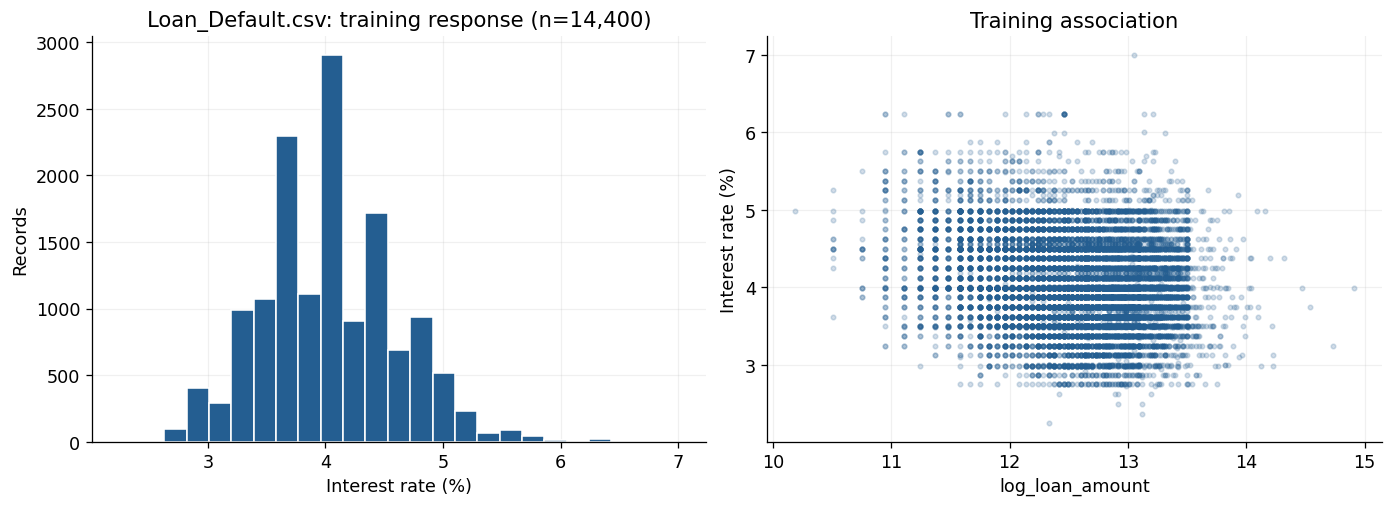

,Training response
count,"14,400.0000"
mean,4.0353
std,0.5600
min,2.2500
25%,3.6250
50%,3.9900
75%,4.3750
max,7.0000


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), layout='constrained')
axes[0].hist(y_train, bins=min(25, max(5, len(y_train)//3)), color=BLUE, edgecolor='white')
axes[0].set(title=f'{dataset_name}: training response (n={len(y_train):,})',
            xlabel=response_axis, ylabel='Records')
axes[1].scatter(X_train[numeric[0]], y_train, s=20 if len(y_train)<100 else 8,
                alpha=0.8 if len(y_train)<100 else 0.2, color=BLUE)
axes[1].set(title='Training association', xlabel=numeric[0],
            ylabel=response_axis)
plt.show()
display(y_train.describe().rename('Training response').to_frame())

### B4. Check multicollinearity and VIF in this dataset

Compute VIF using training data only. The bank example deliberately includes age in years and months to expose exact unit redundancy; the mortgage example checks observed loan amount, property value, LTV, income, credit score, and term. The fitted design uses one representation per feature and reference-coded categories.

In [15]:
if dataset_name == 'bank_customers.csv':
    redundant = X_train[['age_years']].assign(age_months=X_train['age_years'] * 12)
else:
    columns = ['loan_amount', 'property_value', 'LTV', 'income', 'Credit_Score', 'term']
    redundant = frame.loc[X_train.index, columns].astype(float)
    redundant = redundant.fillna(redundant.median())
display(extra_vif(redundant))
fitted_prepare = extra_preprocessor(numeric, categorical).fit(X_train)
design = pd.DataFrame(fitted_prepare.transform(X_train),
                      columns=fitted_prepare.get_feature_names_out())
model_vif = extra_vif(design)
display(model_vif)
rank = np.linalg.matrix_rank(np.column_stack([np.ones(len(design)), design]))
print(f'Additive design rank with intercept: {rank}/{design.shape[1]+1}')
assert rank == design.shape[1] + 1

,feature,VIF
1,property_value,4.6521
0,loan_amount,3.7244
2,LTV,2.3747
3,income,1.2016
5,term,1.1126
4,Credit_Score,1.0003


,feature,VIF
1,log_income,2.5981
0,log_loan_amount,2.4079
9,loan_purpose_p3,2.1194
10,loan_purpose_p4,1.9706
4,LTV,1.5801
11,occupancy_type_pr,1.5616
12,occupancy_type_sr,1.4546
5,dtir1,1.4235
6,loan_type_type2,1.2551
3,term,1.1961


Additive design rank with intercept: 14/14


### B5. Fit linear, polynomial, and interaction specifications

Additive OLS includes continuous and categorical predictors. The quadratic model adds squares of standardized continuous predictors. The interaction model additionally interacts the first continuous feature with the others and each category indicator. Parent terms remain present. For bank data this tests whether the age–tenure slope differs by account type. Use CV for diagnostics and validation RMSE for form selection.

In [16]:
fitted = {}
rows = []
for label, mode in [('Additive OLS', 'linear'), ('Quadratic OLS', 'quadratic'),
                    ('Quadratic + interactions', 'interaction')]:
    estimator = extra_regressor(numeric, categorical, mode=mode)
    cv_errors = -cross_val_score(estimator, X_train, y_train, cv=folds,
                                  scoring='neg_root_mean_squared_error', error_score='raise')
    estimator.fit(X_train, y_train)
    fitted[label] = estimator
    rows.append({'model': label, 'CV RMSE': cv_errors.mean(),
        'CV fold SD': cv_errors.std(ddof=1),
        'Train RMSE': extra_metrics(y_train, estimator.predict(X_train))['RMSE'],
        **extra_metrics(y_valid, estimator.predict(X_valid))})
validation = pd.DataFrame(rows).set_index('model')
display(validation.sort_values('RMSE'))
chosen_name = validation['RMSE'].idxmin()
coefficients = pd.Series(fitted[chosen_name].named_steps['model'].coef_,
    index=fitted[chosen_name][:-1].get_feature_names_out(), name=f'Coefficient ({outcome_unit})')
display(coefficients.loc[coefficients.abs().nlargest(min(10,len(coefficients))).index].to_frame())
encoder = fitted[chosen_name].named_steps['prepare'].named_transformers_['cat'].named_steps['encode']
display(pd.Series({name: levels[0] for name, levels in zip(categorical, encoder.categories_)},
                  name='Reference category'))

,CV RMSE,CV fold SD,Train RMSE,RMSE,MAE,R²
model,,,,,,
Quadratic + interactions,0.4434,0.0072,0.4416,0.4401,0.3424,0.3932
Quadratic OLS,0.4444,0.0071,0.4430,0.4415,0.3442,0.3895
Additive OLS,0.4517,0.0087,0.4508,0.4512,0.3522,0.3624


,Coefficient (percentage points)
loan_type_type3,-0.6685
occupancy_type_sr,-0.6208
occupancy_type_pr,-0.5251
loan_purpose_p2,0.3958
loan_type_type2,-0.3729
loan_purpose_p3,0.2206
loan_purpose_p4,-0.1439
LTV,0.1428
log_loan_amount,-0.1235
log_income,0.1090


loan_type         type1
loan_purpose         p1
occupancy_type       ir
Name: Reference category, dtype: str

### B6. Visualize the model comparison and conditional relationship

Keep the observed units in the error comparison. The conditional curve uses training medians and category modes and stays within the central training range. It illustrates the fitted equation; it is not a causal intervention.

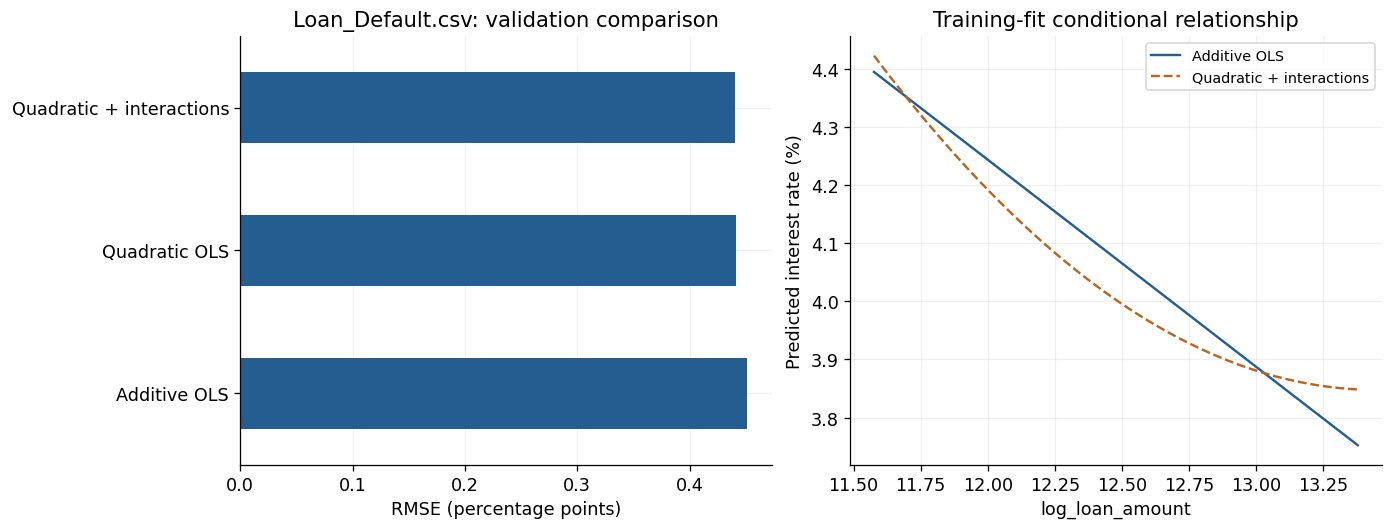

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout='constrained')
validation['RMSE'].plot.barh(ax=axes[0], color=BLUE)
axes[0].set(title=f'{dataset_name}: validation comparison', xlabel=f'RMSE ({outcome_unit})', ylabel='')
typical = {name: X_train[name].median() for name in numeric}
typical.update({name: X_train[name].mode().iloc[0] for name in categorical})
grid = np.linspace(*X_train[numeric[0]].quantile([0.05, 0.95]), 60)
profile = pd.DataFrame([typical]*len(grid))
profile[numeric[0]] = grid
for label, color, style in [('Additive OLS', BLUE, '-'),
                             ('Quadratic + interactions', ORANGE, '--')]:
    axes[1].plot(grid, fitted[label].predict(profile), color=color, linestyle=style, label=label)
axes[1].set(title='Training-fit conditional relationship', xlabel=numeric[0],
            ylabel=f'Predicted {response_axis.lower()}')
axes[1].legend(fontsize=9)
plt.show()
method_finding = (f"Additive and interaction-model validation RMSEs were "
    f"**{validation.loc['Additive OLS','RMSE']:.3f}** and "
    f"**{validation.loc['Quadratic + interactions','RMSE']:.3f} {outcome_unit}**. "
    f"The retained additive design was full rank, with maximum individual-column VIF "
    f"**{model_vif['VIF'].max():.2f}**. Polynomial expansion remains linear in its coefficients; "
    "extra flexibility is justified by held-out error, not training fit alone.")

### B7. Evaluate and diagnose this dataset’s final model

Freeze the validation-selected family/configuration, refit on development rows, and evaluate on the test partition. Report the mean-only baseline, residuals, and the test sample size. Negative R² is retained when the model underperforms.

,RMSE,MAE,R²
Quadratic + interactions,0.4424,0.3488,0.3547
Development-mean baseline,0.5510,0.4368,-0.0011


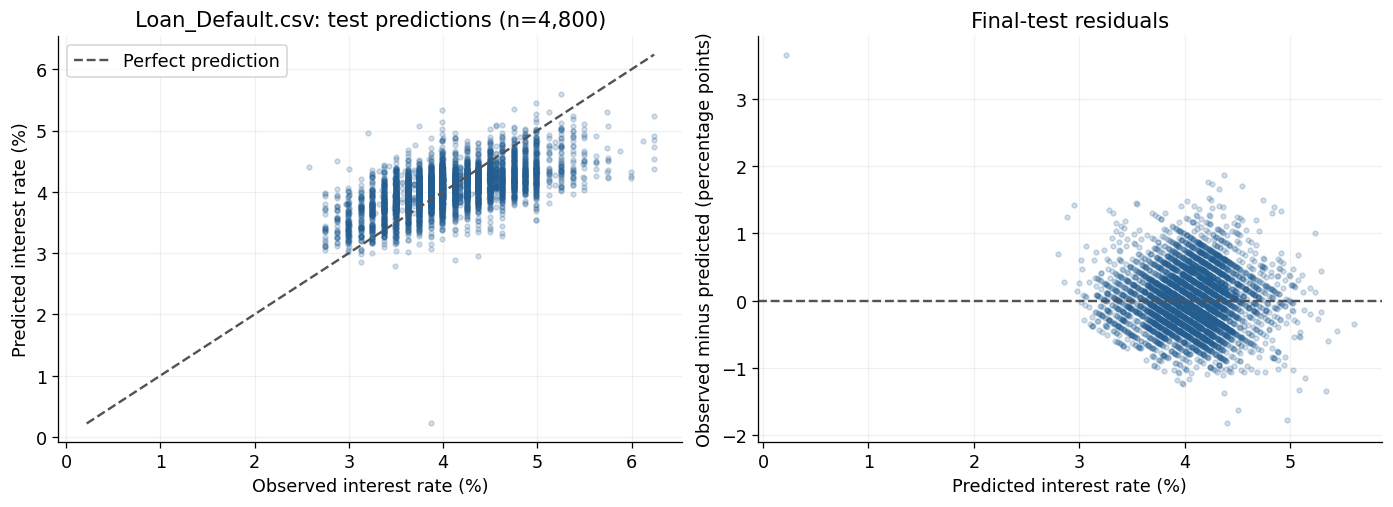

In [18]:
final_model = clone(fitted[chosen_name]).fit(X_dev, y_dev)
prediction = np.asarray(final_model.predict(X_test)).ravel()
baseline = DummyRegressor().fit(X_dev, y_dev).predict(X_test)
final_scores = extra_metrics(y_test, prediction)
baseline_scores = extra_metrics(y_test, baseline)
display(pd.DataFrame([final_scores, baseline_scores], index=[chosen_name, 'Development-mean baseline']))
residuals = y_test.to_numpy() - prediction
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), layout='constrained')
alpha = 0.8 if len(y_test) < 100 else 0.20
axes[0].scatter(y_test, prediction, color=BLUE, alpha=alpha, s=22 if len(y_test)<100 else 9)
bounds = [min(y_test.min(), prediction.min()), max(y_test.max(), prediction.max())]
axes[0].plot(bounds, bounds, '--', color=GRAY, label='Perfect prediction')
axes[0].set(title=f'{dataset_name}: test predictions (n={len(y_test):,})',
            xlabel=f'Observed {response_axis.lower()}',
            ylabel=f'Predicted {response_axis.lower()}')
axes[0].legend()
axes[1].scatter(prediction, residuals, color=BLUE, alpha=alpha, s=22 if len(y_test)<100 else 9)
axes[1].axhline(0, linestyle='--', color=GRAY)
axes[1].set(title='Final-test residuals', xlabel=f'Predicted {response_axis.lower()}',
            ylabel=f'Observed minus predicted ({outcome_unit})')
plt.show()
assert np.isfinite(prediction).all()
if dataset_name == 'bank_customers.csv':
    print(f'Negative predicted tenure values: {int((prediction < 0).sum())}/{len(prediction)}; values are not clipped.')
dataset_results.append({'dataset': dataset_name, 'outcome': outcome_label, 'unit': outcome_unit,
    'training n': len(y_train), 'test n': len(y_test), 'model': chosen_name,
    **final_scores, 'baseline RMSE': baseline_scores['RMSE']})

### Dataset conclusions — Loan_Default.csv

Validation selected **Quadratic + interactions**. Test RMSE was **0.442 percentage points**, MAE **0.349 percentage points**, and R² **0.355** on **4,800** records. RMSE was **lower** than the development-mean baseline (**0.551 percentage points**).

Additive and interaction-model validation RMSEs were **0.451** and **0.440 percentage points**. The retained additive design was full rank, with maximum individual-column VIF **2.60**. Polynomial expansion remains linear in its coefficients; extra flexibility is justified by held-out error, not training fit alone.

The outcome is observed pricing in an eligible subset that excludes nearly all Status 1 records. It does not generalize to missing-rate loans or establish default risk.

## C. bank_customers.csv — independent analysis

The continuous response is **account tenure in years as of September 26, 2026**. Predictors are age at that same date and account type. This is a retrospective account-profile association, not a loan/default model or a causal forecast. Opening date is used only to calculate the response and is excluded from predictors.

**Date and grain decisions.** Exclude future opening dates, missing/unparseable/partial
birth dates, dates after the reference date, opening before birth, and unrecognized account
types. Year-only birth dates are not converted into invented full dates. Eligibility flags
can overlap. Account openings during childhood are retained because custodial accounts are
possible; product eligibility is not documented. Repeated account IDs stay together in
train/validation/test and CV. IDs are group keys, not numeric predictors.

**Interpretation limit.** The original file has only 100 rows and many invalid dates.
The valid subset is very small and not representative of all records. Exact predictive
scores will be unstable; these models demonstrate the weekly methods on genuine observed
account fields. Derived age and tenure share a reference date; their association can
partly reflect the arithmetic constraint that an account cannot predate birth.
SSNs are excluded at read time and identifiers are never displayed.

### C1. Load, audit, and define this dataset’s response

Reconcile the original rows with the eligible modeling population. Features and targets are built from this file alone; no dataset is joined to another.

In [19]:
dataset_name = 'bank_customers.csv'
source_frame = pd.read_csv(DATA_DIR / dataset_name, usecols=lambda name: name != 'SSN')
AS_OF = pd.Timestamp('2026-09-26')
birth_text = source_frame['BirthDate'].astype('string').str.strip()
partial_birth = birth_text.str.fullmatch(r'\d{4}', na=False)
birth = pd.to_datetime(birth_text.mask(partial_birth), format='mixed', errors='coerce')
opened = pd.to_datetime(source_frame['AccountOpened'], format='mixed', errors='coerce')
valid_type = source_frame['AccountType'].isin(['checking', 'savings', 'cd'])
eligible = (birth.notna() & opened.notna() & birth.le(AS_OF) & opened.le(AS_OF)
            & opened.ge(birth) & valid_type)
# Reason flags overlap; the union, not their sum, determines exclusions.
display(pd.Series({'source records': len(source_frame),
    'missing/invalid/partial birth date': birth.isna().sum(),
    'missing/invalid opening date': opened.isna().sum(),
    'future opening date': opened.gt(AS_OF).sum(),
    'opening before exact birth date': opened.lt(birth).sum(),
    'missing/unrecognized account type': (~valid_type).sum(),
    'eligible records': eligible.sum(), 'excluded union': (~eligible).sum()}, name='Bank eligibility audit'))
frame = source_frame.loc[eligible].copy()
frame['age_years'] = (AS_OF - birth.loc[eligible]).dt.days / 365.25
frame['tenure_years'] = (AS_OF - opened.loc[eligible]).dt.days / 365.25
# Repeated AccountID values are conservatively grouped, even though this file
# does not document whether they represent shared accounts or data-quality issues.
frame['_group'] = frame['AccountID'].astype('string')
frame['_group'] = frame['_group'].fillna(pd.Series(
    ['missing_account_' + str(i) for i in frame.index], index=frame.index))
frame = frame.reset_index(drop=True)
groups = frame['_group']
assert len(frame) >= 20
display(frame['AccountType'].value_counts().rename('eligible records').to_frame())
# BirthDate, CustomerID, AccountID, and SSN are never displayed or used as model features.

outcome_label, outcome_unit = 'account tenure', 'years'
response_axis = 'Account tenure (years)'
X = frame[['age_years', 'AccountType']].copy()
y = frame['tenure_years']
numeric, categorical = ['age_years'], ['AccountType']

source records                        100
missing/invalid/partial birth date      3
missing/invalid opening date            1
future opening date                    59
opening before exact birth date         0
missing/unrecognized account type       1
eligible records                       39
excluded union                         61
Name: Bank eligibility audit, dtype: int64

,eligible records
AccountType,
checking,16
savings,15
cd,8


### C2. Reserve evaluation records and inspect training data

The bank file uses account-group splits and group CV; loan files use row splits. Imputation, encoding, scaling, selection, and dimension reduction remain inside training folds. The small bank partitions can have substantially different outcome distributions.

In [20]:
train_index, valid_index, test_index, dev_index, folds = extra_split(X, y, groups, classification=False)
X_train, X_valid, X_test, X_dev = [X.iloc[index] for index in [train_index, valid_index, test_index, dev_index]]
y_train, y_valid, y_test, y_dev = [y.iloc[index] for index in [train_index, valid_index, test_index, dev_index]]
split_table = pd.DataFrame({'records': [len(y_train), len(y_valid), len(y_test)],
    'response mean': [y_train.mean(), y_valid.mean(), y_test.mean()]}, index=['training', 'validation', 'test'])
if groups is not None:
    split_table['account groups'] = [groups.iloc[index].nunique() for index in [train_index, valid_index, test_index]]
display(split_table)
display(X_train.isna().mean().mul(100).rename('Training missing (%)').to_frame())

,records,response mean,account groups
training,24,26.3941,21
validation,7,20.7228,7
test,8,18.8433,8


,Training missing (%)
age_years,0.0000
AccountType,0.0000


### C3. Explore this dataset’s training response

Show the response distribution and its relationship with the first continuous predictor. Large-loan samples use translucent points; the bank plot displays every training record. These associations do not establish causation.

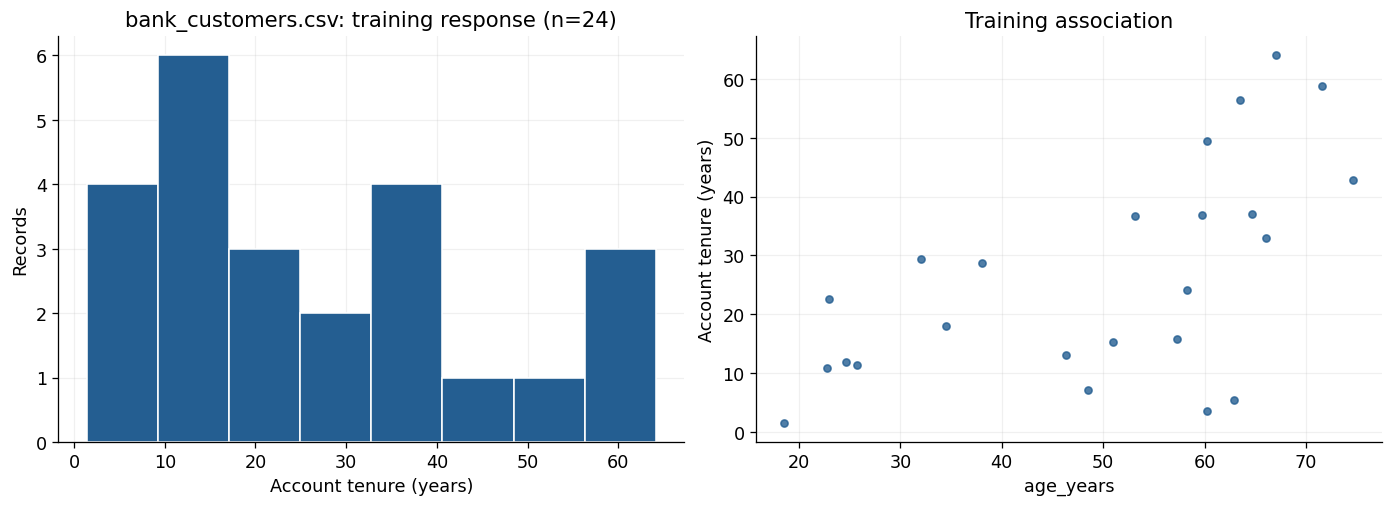

,Training response
count,24.0000
mean,26.3941
std,18.3239
min,1.3990
25%,11.6797
50%,23.3566
75%,36.9103
max,64.1396


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), layout='constrained')
axes[0].hist(y_train, bins=min(25, max(5, len(y_train)//3)), color=BLUE, edgecolor='white')
axes[0].set(title=f'{dataset_name}: training response (n={len(y_train):,})',
            xlabel=response_axis, ylabel='Records')
axes[1].scatter(X_train[numeric[0]], y_train, s=20 if len(y_train)<100 else 8,
                alpha=0.8 if len(y_train)<100 else 0.2, color=BLUE)
axes[1].set(title='Training association', xlabel=numeric[0],
            ylabel=response_axis)
plt.show()
display(y_train.describe().rename('Training response').to_frame())

### C4. Check multicollinearity and VIF in this dataset

Compute VIF using training data only. The bank example deliberately includes age in years and months to expose exact unit redundancy; the mortgage example checks observed loan amount, property value, LTV, income, credit score, and term. The fitted design uses one representation per feature and reference-coded categories.

In [22]:
if dataset_name == 'bank_customers.csv':
    redundant = X_train[['age_years']].assign(age_months=X_train['age_years'] * 12)
else:
    columns = ['loan_amount', 'property_value', 'LTV', 'income', 'Credit_Score', 'term']
    redundant = frame.loc[X_train.index, columns].astype(float)
    redundant = redundant.fillna(redundant.median())
display(extra_vif(redundant))
fitted_prepare = extra_preprocessor(numeric, categorical).fit(X_train)
design = pd.DataFrame(fitted_prepare.transform(X_train),
                      columns=fitted_prepare.get_feature_names_out())
model_vif = extra_vif(design)
display(model_vif)
rank = np.linalg.matrix_rank(np.column_stack([np.ones(len(design)), design]))
print(f'Additive design rank with intercept: {rank}/{design.shape[1]+1}')
assert rank == design.shape[1] + 1

,feature,VIF
0,age_years,inf
1,age_months,inf


,feature,VIF
2,AccountType_savings,1.4849
1,AccountType_checking,1.4456
0,age_years,1.0394


Additive design rank with intercept: 4/4


### C5. Fit linear, polynomial, and interaction specifications

Additive OLS includes continuous and categorical predictors. The quadratic model adds squares of standardized continuous predictors. The interaction model additionally interacts the first continuous feature with the others and each category indicator. Parent terms remain present. For bank data this tests whether the age–tenure slope differs by account type. Use CV for diagnostics and validation RMSE for form selection.

In [23]:
fitted = {}
rows = []
for label, mode in [('Additive OLS', 'linear'), ('Quadratic OLS', 'quadratic'),
                    ('Quadratic + interactions', 'interaction')]:
    estimator = extra_regressor(numeric, categorical, mode=mode)
    cv_errors = -cross_val_score(estimator, X_train, y_train, cv=folds,
                                  scoring='neg_root_mean_squared_error', error_score='raise')
    estimator.fit(X_train, y_train)
    fitted[label] = estimator
    rows.append({'model': label, 'CV RMSE': cv_errors.mean(),
        'CV fold SD': cv_errors.std(ddof=1),
        'Train RMSE': extra_metrics(y_train, estimator.predict(X_train))['RMSE'],
        **extra_metrics(y_valid, estimator.predict(X_valid))})
validation = pd.DataFrame(rows).set_index('model')
display(validation.sort_values('RMSE'))
chosen_name = validation['RMSE'].idxmin()
coefficients = pd.Series(fitted[chosen_name].named_steps['model'].coef_,
    index=fitted[chosen_name][:-1].get_feature_names_out(), name=f'Coefficient ({outcome_unit})')
display(coefficients.loc[coefficients.abs().nlargest(min(10,len(coefficients))).index].to_frame())
encoder = fitted[chosen_name].named_steps['prepare'].named_transformers_['cat'].named_steps['encode']
display(pd.Series({name: levels[0] for name, levels in zip(categorical, encoder.categories_)},
                  name='Reference category'))

,CV RMSE,CV fold SD,Train RMSE,RMSE,MAE,R²
model,,,,,,
Additive OLS,19.0801,2.7902,14.0658,19.8199,16.5448,0.2201
Quadratic OLS,18.4262,2.6789,13.5017,19.8959,16.2688,0.2141
Quadratic + interactions,24.1314,4.8535,13.3676,20.7808,16.9970,0.1427


,Coefficient (years)
age_years,10.3675
AccountType_checking,-8.4272
AccountType_savings,-2.9218


AccountType    cd
Name: Reference category, dtype: str

### C6. Visualize the model comparison and conditional relationship

Keep the observed units in the error comparison. The conditional curve uses training medians and category modes and stays within the central training range. It illustrates the fitted equation; it is not a causal intervention.

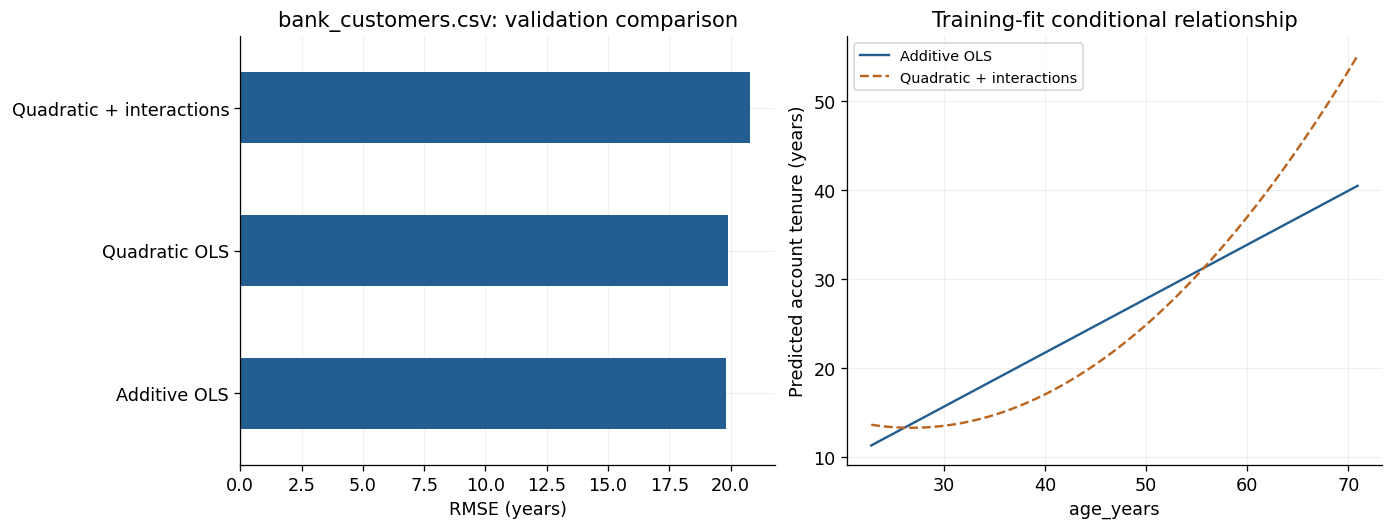

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout='constrained')
validation['RMSE'].plot.barh(ax=axes[0], color=BLUE)
axes[0].set(title=f'{dataset_name}: validation comparison', xlabel=f'RMSE ({outcome_unit})', ylabel='')
typical = {name: X_train[name].median() for name in numeric}
typical.update({name: X_train[name].mode().iloc[0] for name in categorical})
grid = np.linspace(*X_train[numeric[0]].quantile([0.05, 0.95]), 60)
profile = pd.DataFrame([typical]*len(grid))
profile[numeric[0]] = grid
for label, color, style in [('Additive OLS', BLUE, '-'),
                             ('Quadratic + interactions', ORANGE, '--')]:
    axes[1].plot(grid, fitted[label].predict(profile), color=color, linestyle=style, label=label)
axes[1].set(title='Training-fit conditional relationship', xlabel=numeric[0],
            ylabel=f'Predicted {response_axis.lower()}')
axes[1].legend(fontsize=9)
plt.show()
method_finding = (f"Additive and interaction-model validation RMSEs were "
    f"**{validation.loc['Additive OLS','RMSE']:.3f}** and "
    f"**{validation.loc['Quadratic + interactions','RMSE']:.3f} {outcome_unit}**. "
    f"The retained additive design was full rank, with maximum individual-column VIF "
    f"**{model_vif['VIF'].max():.2f}**. Polynomial expansion remains linear in its coefficients; "
    "extra flexibility is justified by held-out error, not training fit alone.")

### C7. Evaluate and diagnose this dataset’s final model

Freeze the validation-selected family/configuration, refit on development rows, and evaluate on the test partition. Report the mean-only baseline, residuals, and the test sample size. Negative R² is retained when the model underperforms.

,RMSE,MAE,R²
Additive OLS,10.8170,8.8571,-0.0825
Development-mean baseline,12.1410,10.3660,-0.3637


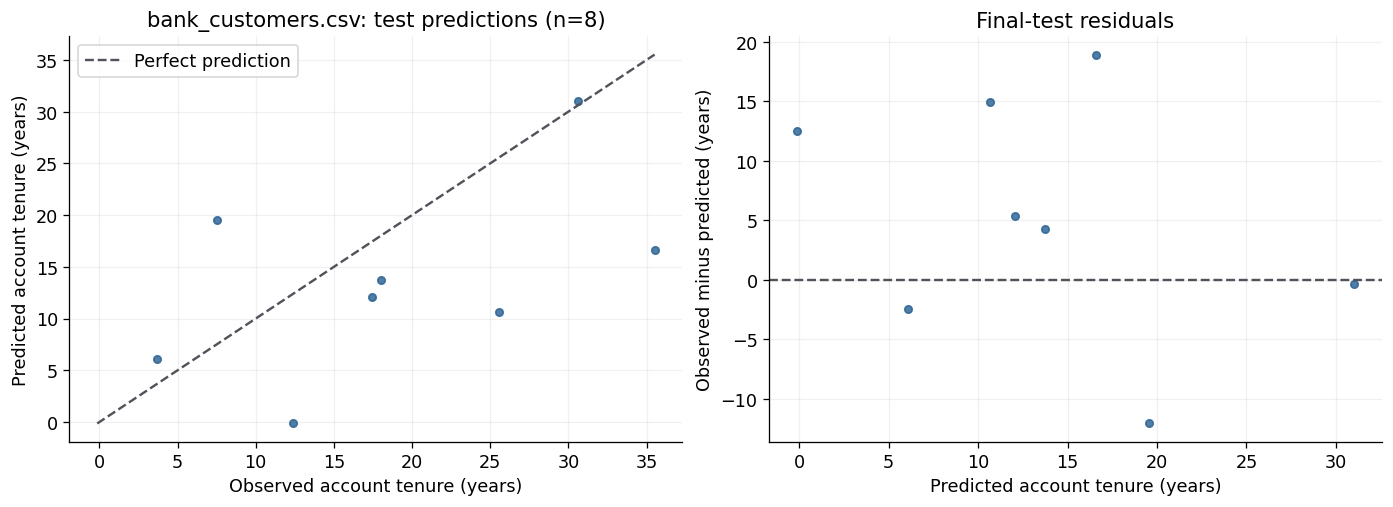

Negative predicted tenure values: 1/8; values are not clipped.


In [25]:
final_model = clone(fitted[chosen_name]).fit(X_dev, y_dev)
prediction = np.asarray(final_model.predict(X_test)).ravel()
baseline = DummyRegressor().fit(X_dev, y_dev).predict(X_test)
final_scores = extra_metrics(y_test, prediction)
baseline_scores = extra_metrics(y_test, baseline)
display(pd.DataFrame([final_scores, baseline_scores], index=[chosen_name, 'Development-mean baseline']))
residuals = y_test.to_numpy() - prediction
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), layout='constrained')
alpha = 0.8 if len(y_test) < 100 else 0.20
axes[0].scatter(y_test, prediction, color=BLUE, alpha=alpha, s=22 if len(y_test)<100 else 9)
bounds = [min(y_test.min(), prediction.min()), max(y_test.max(), prediction.max())]
axes[0].plot(bounds, bounds, '--', color=GRAY, label='Perfect prediction')
axes[0].set(title=f'{dataset_name}: test predictions (n={len(y_test):,})',
            xlabel=f'Observed {response_axis.lower()}',
            ylabel=f'Predicted {response_axis.lower()}')
axes[0].legend()
axes[1].scatter(prediction, residuals, color=BLUE, alpha=alpha, s=22 if len(y_test)<100 else 9)
axes[1].axhline(0, linestyle='--', color=GRAY)
axes[1].set(title='Final-test residuals', xlabel=f'Predicted {response_axis.lower()}',
            ylabel=f'Observed minus predicted ({outcome_unit})')
plt.show()
assert np.isfinite(prediction).all()
if dataset_name == 'bank_customers.csv':
    print(f'Negative predicted tenure values: {int((prediction < 0).sum())}/{len(prediction)}; values are not clipped.')
dataset_results.append({'dataset': dataset_name, 'outcome': outcome_label, 'unit': outcome_unit,
    'training n': len(y_train), 'test n': len(y_test), 'model': chosen_name,
    **final_scores, 'baseline RMSE': baseline_scores['RMSE']})

### Dataset conclusions — bank_customers.csv

Validation selected **Additive OLS**. Test RMSE was **10.817 years**, MAE **8.857 years**, and R² **-0.083** on **8** records. RMSE was **lower** than the development-mean baseline (**12.141 years**).

Additive and interaction-model validation RMSEs were **19.820** and **20.781 years**. The retained additive design was full rank, with maximum individual-column VIF **1.48**. Polynomial expansion remains linear in its coefficients; extra flexibility is justified by held-out error, not training fit alone.

Only a small historical, date-valid subset is modeled; account-group separation prevents repeat-account leakage but leaves very few validation/test observations. Scores are descriptive demonstrations, not stable estimates of customer behavior.

**Baseline interpretation:** R² compares predictions with the mean of this particular test set. The fitted baseline uses the development-set mean, so a model can beat that feasible baseline while still having negative test R². Unconstrained OLS can also produce negative tenure; the validity count printed above is retained rather than silently clipping predictions.

## Method references

- [scikit-learn: linear models](https://scikit-learn.org/stable/modules/linear_model.html)
- [scikit-learn: preprocessing](https://scikit-learn.org/stable/modules/preprocessing.html)
- [scikit-learn: feature selection](https://scikit-learn.org/stable/modules/feature_selection.html)
- [scikit-learn: PCR versus PLS](https://scikit-learn.org/stable/auto_examples/cross_decomposition/plot_pcr_vs_pls.html)

Dataset observations in this notebook come from the local CSV files; the links explain methods, not dataset provenance. The original assignment text is preserved above. Its omitted Milestone One rubric/link still needs to be checked before final submission.

### Reconcile coverage across the three datasets

Each row comes from a separately fitted workflow above. Response units and sample sizes are retained to prevent false comparisons between different tasks.

In [26]:
all_dataset_results = pd.DataFrame(dataset_results).set_index('dataset')
assert set(all_dataset_results.index) == {
    'accepted_2007_to_2018Q4.csv','Loan_Default.csv','bank_customers.csv'}
with pd.option_context('display.max_columns',None,'display.max_colwidth',75):
    display(all_dataset_results)

,outcome,unit,training n,test n,model,RMSE,MAE,R²,baseline RMSE
dataset,,,,,,,,,
accepted_2007_to_2018Q4.csv,issued interest rate,percentage points,14400,4800,Quadratic + interaction,3.0642,2.4146,0.4917,4.2988
Loan_Default.csv,observed interest rate,percentage points,14400,4800,Quadratic + interactions,0.4424,0.3488,0.3547,0.5510
bank_customers.csv,account tenure,years,24,8,Additive OLS,10.8170,8.8571,-0.0825,12.1410


## Overall conclusions

- **accepted_2007_to_2018Q4.csv**: Quadratic + interaction; test RMSE **3.064 percentage points**, MAE **2.415 percentage points**, R² **0.492**, test n = **4,800**. Development-mean baseline RMSE: **4.299 percentage points**.
- **Loan_Default.csv**: Quadratic + interactions; test RMSE **0.442 percentage points**, MAE **0.349 percentage points**, R² **0.355**, test n = **4,800**. Development-mean baseline RMSE: **0.551 percentage points**.
- **bank_customers.csv**: Additive OLS; test RMSE **10.817 years**, MAE **8.857 years**, R² **-0.083**, test n = **8**. Development-mean baseline RMSE: **12.141 years**.

Each dataset now has its own full application of this week's required methods. LendingClub models issued rates in a 2015 cohort; Loan_Default models observed rates in a heavily selected subset; bank_customers models historical account tenure. Their errors use different populations and, for the bank file, different units. The small bank holdout is a method demonstration, not a reliable performance claim. The dataset-specific conclusions above explain the observed selection, shrinkage, or component tradeoff. No result establishes causality or future-cohort validity.